# Cloud Catalyst Model Validation

## Setup

In [1]:
import importlib
import logging
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from use_core import constants, run_info, task

sys.path.insert(0, "..")
build_models = importlib.import_module("build-models")

sns.set()

run_info.logger.setLevel(logging.CRITICAL)

In [2]:
class MockRunConfig:
    def __init__(
        self,
        dedup_ratio: float,
        kb_transferred: int,
        num_streams: int,
        task: str,
        workload_type: str,
        io_duplex: task.TaskDuplexType,
    ) -> None:
        self.dedup_ratio = dedup_ratio
        self.kb_transferred = kb_transferred
        self.num_streams = num_streams
        self.task = task
        self.workload_type = workload_type
        self.io_duplex = io_duplex

class MockApplianceConfig:
    def __init__(
        self,
        appliance: str,
        site_version: str,
        memory: int,
        number_of_total_drives: int,
    ) -> None:
        self.appliance = appliance
        self.site_version = site_version
        self.memory = memory
        self.number_of_total_drives = number_of_total_drives

## Master and CC

In [3]:
mock_run_config = MockRunConfig(0.47, 1000000, 10, "backup", "ma_cc", task.TaskDuplexType.half)
mock_appliance_config = MockApplianceConfig("5150", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)
ri = run_info.RunInfo(mock_run_config,
                      mock_appliance_config,
                      retrain=True,
                      root_data_dir="../data",
                      model_dir="../src/core/use_core/conf/models")

In [4]:
fitted_model = ri.cpu_model
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.983
Method:                 Least Squares   F-statistic:                              477.7
Date:                Fri, 24 Jan 2020   Prob (F-statistic):                    1.79e-19
Time:                        16:51:54   Log-Likelihood:                         -168.56
No. Observations:                  24   AIC:                                      343.1
Df Residuals:                      21   BIC:                                      346.7
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0046      0.001      4.992      0.000       0.003       0.006
kb_transferred:dedup_ratio    -0.0040      0.001     -4.473      0.000      -0.006      -0.002
swapout                        0.0207      0.009      2.245      0.036       0.002       0.040
==============================================================================
Omnibus:                        2.978   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.226   Jarque-Bera (JB):                1.415
Skew:                          -0.341   Prob(JB):                        0.493
Kurtosis:                       3.975   Cond. No.                         106.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

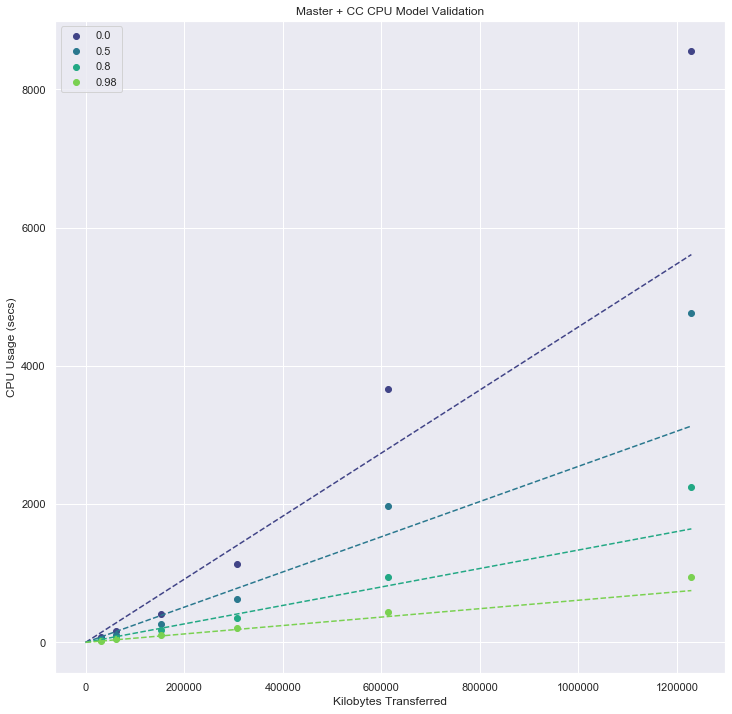

In [5]:
root_data_dir = pathlib.Path("../data")
data_dir_5150 = root_data_dir / "5150/8.2/ma_cc"
cpu_data = build_models.get_cpu_data(data_dir_5150, "backup", "ma_cc", "5150")
dedup_cat = cpu_data["dedup_ratio"].astype("category")
colors = sns.color_palette("viridis", 4)

max_kb_transferred = cpu_data["kb_transferred"].max()

fig, ax = plt.subplots(figsize=(12, 12))
for i, ddr in enumerate(dedup_cat.cat.categories):
    # Scatter points
    subset_dat = cpu_data.loc[cpu_data["dedup_ratio"] == ddr]
    ax.scatter(subset_dat["kb_transferred"], subset_dat["cpu_usage_secs"], c=[colors[i]], label=str(ddr))

    # Fitted line
    input_range = np.linspace(0, max_kb_transferred, 1000)
    pred_vals = fitted_model.predict(pd.DataFrame({"kb_transferred": input_range, "dedup_ratio": [ddr] * len(input_range), "swapout": [0] * len(input_range)}))
    ax.plot(input_range, pred_vals, c=colors[i], ls="--")
ax.set(title="Master + CC CPU Model Validation", xlabel="Kilobytes Transferred", ylabel="CPU Usage (secs)")
ax.legend(loc="upper left");

## Master, MSDP, and CC

In [6]:
mock_run_config = MockRunConfig(0.47, 1000000, 10, "backup", "ma_msdp_cc", task.TaskDuplexType.half)
mock_appliance_config = MockApplianceConfig("5150", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)
ri = run_info.RunInfo(mock_run_config,
                      mock_appliance_config,
                      retrain=True,
                      root_data_dir="../src/main/python/conf/data",
                      model_dir="../src/main/python/conf/models")

In [7]:
fitted_model = ri.cpu_model
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.988
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              555.4
Date:                Fri, 24 Jan 2020   Prob (F-statistic):                    3.75e-20
Time:                        16:51:55   Log-Likelihood:                         -165.02
No. Observations:                  24   AIC:                                      336.0
Df Residuals:                      21   BIC:                                      339.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0031      0.001      5.189      0.000       0.002       0.004
kb_transferred:dedup_ratio    -0.0024      0.001     -3.717      0.001      -0.004      -0.001
swapout                        0.1172      0.024      4.974      0.000       0.068       0.166
==============================================================================
Omnibus:                       33.339   Durbin-Watson:                   2.331
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              104.644
Skew:                           2.326   Prob(JB):                     1.89e-23
Kurtosis:                      12.111   Cond. No.                         312.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

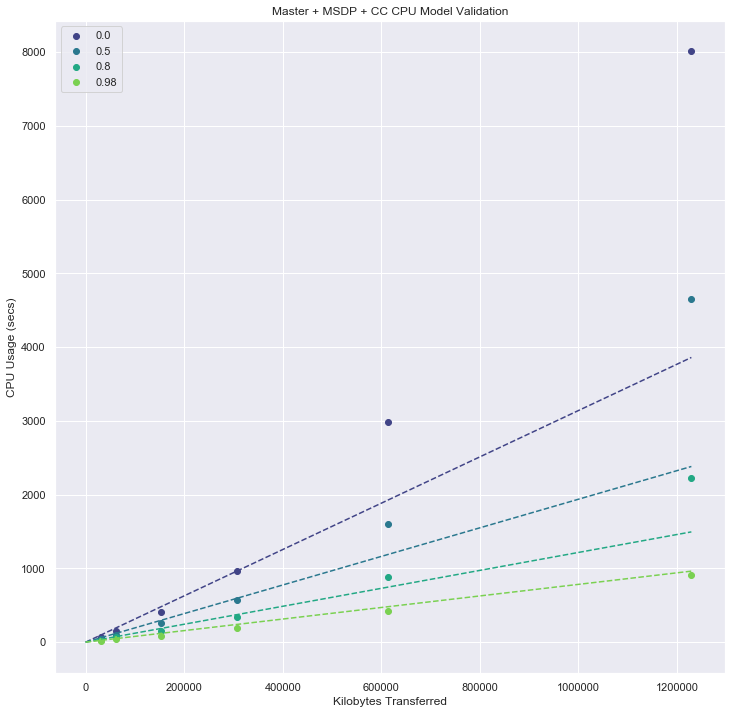

In [8]:
root_data_dir = pathlib.Path("../data")
data_dir_5150 = root_data_dir / "5150/8.2/ma_msdp_cc"
cpu_data = build_models.get_cpu_data(data_dir_5150, "backup", "ma_msdp_cc", "5150")
dedup_cat = cpu_data["dedup_ratio"].astype("category")
colors = sns.color_palette("viridis", 4)

max_kb_transferred = cpu_data["kb_transferred"].max()

fig, ax = plt.subplots(figsize=(12, 12))
for i, ddr in enumerate(dedup_cat.cat.categories):
    # Scatter points
    subset_dat = cpu_data.loc[cpu_data["dedup_ratio"] == ddr]
    ax.scatter(subset_dat["kb_transferred"], subset_dat["cpu_usage_secs"], c=[colors[i]], label=str(ddr))

    # Fitted line
    input_range = np.linspace(0, max_kb_transferred, 1000)
    pred_vals = fitted_model.predict(pd.DataFrame({"kb_transferred": input_range, "dedup_ratio": [ddr] * len(input_range), "swapout": [0] * len(input_range)}))
    ax.plot(input_range, pred_vals, c=colors[i], ls="--")
ax.set(title="Master + MSDP + CC CPU Model Validation", xlabel="Kilobytes Transferred", ylabel="CPU Usage (secs)")
ax.legend(loc="upper left");